# Notebook 04: Integration Analysis and Reporting Gaps

## Project 8: Digital Trace Data Collection for Conflict Research

### Overview

In this notebook, I bring together all collected data sources and answer the project's research questions:

1. **Does GDELT media attention to the Tigray conflict correlate with conflict intensity recorded in UCDP event data?**
2. **Where do reporting gaps and surges occur, and what explains them?**

These questions address the data-generating process behind conflict datasets. UCDP, ACLED, and similar datasets depend on media and NGO reporting. If reporting drops during a communications blackout, the dataset underestimates violence. By comparing GDELT media coverage to UCDP event counts, I measure the information environment that feeds the conflict data ecosystem.

**Data sources integrated:**
- **UCDP GED v25.1** from [Conflict Event Data Analysis and Geospatial Visualization](https://github.com/Sezibra/conflict-event-analysis): georeferenced conflict events for Ethiopia (Nov 2020 to Nov 2022). This is the reference dataset recording actual violence.
- **GDELT conflict events** from Notebook 02: media-reported conflict events collected via BigQuery. This captures international media attention.
- **ReliefWeb humanitarian reports** from Notebook 01: UN and NGO situation reports (loaded if available).

**What I learn here:**
- How to align datasets with different structures on a common time axis
- How to calculate and interpret cross-source correlations
- How to identify and explain reporting gaps and surges
- How to create publication-quality multi-panel figures

## 1. Setup and Data Loading

I load all available datasets and align them on a monthly time axis. The UCDP data requires filtering to Ethiopia and the study period, then aggregating to monthly counts. The GDELT monthly aggregation was pre-computed in Notebook 02.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from datetime import datetime

# Set working directory
os.chdir('/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection')

print('Working directory:', os.getcwd())

Working directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection


## 2. Load and Process UCDP Data

I load the UCDP Georeferenced Event Dataset (GED) v25.1 and filter it to Ethiopia during the study period (November 2020 to November 2022). This is the same dataset I used in the [Conflict Event Data Analysis and Geospatial Visualization](https://github.com/Sezibra/conflict-event-analysis).

UCDP records three types of violence:
- Type 1: State-based conflict (government vs. armed group)
- Type 2: Non-state conflict (armed group vs. armed group)
- Type 3: One-sided violence (armed actor vs. civilians)

I aggregate events by month and violence type to create the reference time series.

In [2]:
# Load UCDP GED data
ucdp = pd.read_csv('data/raw/ucdp_ged_v25_1.csv', low_memory=False)

# Filter to Ethiopia and study period
ucdp['date_start'] = pd.to_datetime(ucdp['date_start'])
ucdp_eth = ucdp[
    (ucdp['country'] == 'Ethiopia') &
    (ucdp['date_start'] >= '2020-11-01') &
    (ucdp['date_start'] <= '2022-11-30')
].copy()

# Create year-month column
ucdp_eth['year_month'] = ucdp_eth['date_start'].dt.to_period('M')

# Violence type labels
violence_labels = {1: 'State-based', 2: 'Non-state', 3: 'One-sided'}
ucdp_eth['violence_type'] = ucdp_eth['type_of_violence'].map(violence_labels)

print(f'UCDP Ethiopia events: {len(ucdp_eth)}')
print(f'Date range: {ucdp_eth["date_start"].min().date()} to {ucdp_eth["date_start"].max().date()}')
print(f'\nViolence type breakdown:')
for vtype, count in ucdp_eth['violence_type'].value_counts().items():
    print(f'  {vtype}: {count}')

# Monthly aggregation
ucdp_monthly = ucdp_eth.groupby('year_month').agg(
    ucdp_events=('id', 'size'),
    ucdp_fatalities=('best', 'sum'),
    ucdp_civilian_deaths=('deaths_civilians', 'sum'),
    ucdp_onesided=('type_of_violence', lambda x: (x == 3).sum())
).reset_index()

ucdp_monthly['year_month_str'] = ucdp_monthly['year_month'].astype(str)

print(f'\nMonthly UCDP data: {len(ucdp_monthly)} months')
print(f'Total events: {ucdp_monthly["ucdp_events"].sum()}')
print(f'Total fatalities (best estimate): {ucdp_monthly["ucdp_fatalities"].sum()}')

UCDP Ethiopia events: 1764
Date range: 2020-11-01 to 2022-11-29

Violence type breakdown:
  State-based: 1203
  One-sided: 554
  Non-state: 7

Monthly UCDP data: 25 months
Total events: 1764
Total fatalities (best estimate): 318366


## 3. Load GDELT Monthly Data

I load the GDELT monthly aggregation from Notebook 02. This contains event counts, average Goldstein Scale, average media tone, and total mentions per month for conflict-coded events in Ethiopia.

In [3]:
# Load GDELT monthly data from Notebook 02
gdelt_monthly = pd.read_csv('data/processed/gdelt_monthly_counts.csv')
gdelt_monthly['year_month'] = pd.PeriodIndex(gdelt_monthly['year_month'], freq='M')
gdelt_monthly['year_month_str'] = gdelt_monthly['year_month'].astype(str)

print(f'GDELT monthly data: {len(gdelt_monthly)} months')
print(f'Total conflict events: {gdelt_monthly["event_count"].sum():,}')
print(f'\nColumns: {list(gdelt_monthly.columns)}')
print(f'\nFirst 3 rows:')
print(gdelt_monthly.head(3))

GDELT monthly data: 25 months
Total conflict events: 30,601

Columns: ['year_month', 'event_count', 'avg_goldstein', 'avg_tone', 'total_mentions', 'unique_sources', 'fight_count', 'assault_count', 'mass_violence_count', 'year_month_str']

First 3 rows:
  year_month  event_count  avg_goldstein  avg_tone  total_mentions  \
0    2020-11         3473      -9.059171 -5.469697           21238   
1    2020-12         2285      -8.892166 -5.219121           14305   
2    2021-01         1241      -8.663497 -5.247739            7522   

   unique_sources  fight_count  assault_count  mass_violence_count  \
0            2657         2397            340                   86   
1            1764         1458            241                   59   
2            1009          720            147                   22   

  year_month_str  
0        2020-11  
1        2020-12  
2        2021-01  


## 4. Load ReliefWeb Data (If Available)

I check if the ReliefWeb API collection from Notebook 01 completed. If the data is available, I load the monthly report counts. If not (because the API appname approval is still pending), the analysis proceeds with UCDP and GDELT only. The notebook will work either way.

In [4]:
# Check for ReliefWeb data
reliefweb_path = 'data/processed/reliefweb_monthly_counts.csv'
has_reliefweb = os.path.exists(reliefweb_path)

if has_reliefweb:
    rw_monthly = pd.read_csv(reliefweb_path)
    rw_monthly['year_month'] = pd.PeriodIndex(rw_monthly['year_month'], freq='M')
    rw_monthly['year_month_str'] = rw_monthly['year_month'].astype(str)
    print(f'ReliefWeb monthly data loaded: {len(rw_monthly)} months')
    print(f'Total reports: {rw_monthly["report_count"].sum()}')
else:
    rw_monthly = None
    print('ReliefWeb data not yet available (API appname pending).')
    print('Analysis will proceed with UCDP and GDELT only.')
    print('Re-run this notebook after the ReliefWeb collection completes.')

ReliefWeb data not yet available (API appname pending).
Analysis will proceed with UCDP and GDELT only.
Re-run this notebook after the ReliefWeb collection completes.


## 5. Merge All Sources on Monthly Time Axis

I merge all available datasets on the year-month column to create a single combined DataFrame. Each row represents one month and contains event counts, fatality estimates, media metrics, and (if available) report counts from all sources.

I use an outer join so months that appear in one source but not another are preserved (with NaN values for the missing source). This is important because gaps in one source relative to another are analytically meaningful.

In [5]:
# Start with UCDP as the base
combined = ucdp_monthly[['year_month', 'year_month_str', 'ucdp_events', 
                          'ucdp_fatalities', 'ucdp_civilian_deaths', 'ucdp_onesided']].copy()

# Merge GDELT
gdelt_cols = ['year_month', 'event_count', 'avg_goldstein', 'avg_tone', 
              'total_mentions', 'unique_sources', 'fight_count', 'assault_count', 
              'mass_violence_count']
combined = combined.merge(
    gdelt_monthly[gdelt_cols],
    on='year_month', how='outer'
)
combined = combined.rename(columns={'event_count': 'gdelt_events'})

# Merge ReliefWeb if available
if has_reliefweb:
    combined = combined.merge(
        rw_monthly[['year_month', 'report_count']],
        on='year_month', how='outer'
    )
    combined = combined.rename(columns={'report_count': 'reliefweb_reports'})

# Sort by date
combined = combined.sort_values('year_month').reset_index(drop=True)
combined['year_month_str'] = combined['year_month'].astype(str)

# Fill NaN for display
print(f'Combined dataset: {len(combined)} months')
print(f'\nColumns: {list(combined.columns)}')
print()
print(combined.to_string(index=False))

Combined dataset: 25 months

Columns: ['year_month', 'year_month_str', 'ucdp_events', 'ucdp_fatalities', 'ucdp_civilian_deaths', 'ucdp_onesided', 'gdelt_events', 'avg_goldstein', 'avg_tone', 'total_mentions', 'unique_sources', 'fight_count', 'assault_count', 'mass_violence_count']

year_month year_month_str  ucdp_events  ucdp_fatalities  ucdp_civilian_deaths  ucdp_onesided  gdelt_events  avg_goldstein  avg_tone  total_mentions  unique_sources  fight_count  assault_count  mass_violence_count
   2020-11        2020-11          123            23045                  2502             71          3473      -9.059171 -5.469697           21238            2657         2397            340                   86
   2020-12        2020-12           49              806                   569             35          2285      -8.892166 -5.219121           14305            1764         1458            241                   59
   2021-01        2021-01           92           115738                  1006 

## 6. Multi-Panel Time Series: Violence vs. Media Coverage

This is the central figure of the project. I plot UCDP conflict events and GDELT media events on the same timeline to visually compare violence intensity with media attention.

I annotate key events on the timeline:
- **Nov 2020:** Conflict onset (TPLF attacks Northern Command)
- **Jun 2021:** TPLF retakes Mekelle, humanitarian ceasefire declared
- **Nov 2021:** TPLF offensive toward Addis Ababa, state of emergency
- **Mar 2022:** Humanitarian truce
- **Nov 2022:** Cessation of Hostilities Agreement (Pretoria)

The communications blackout imposed on Tigray from November 2020 is a critical factor. During this period, both media coverage and humanitarian access dropped, which means GDELT captures fewer events and humanitarian reporting gaps widen.

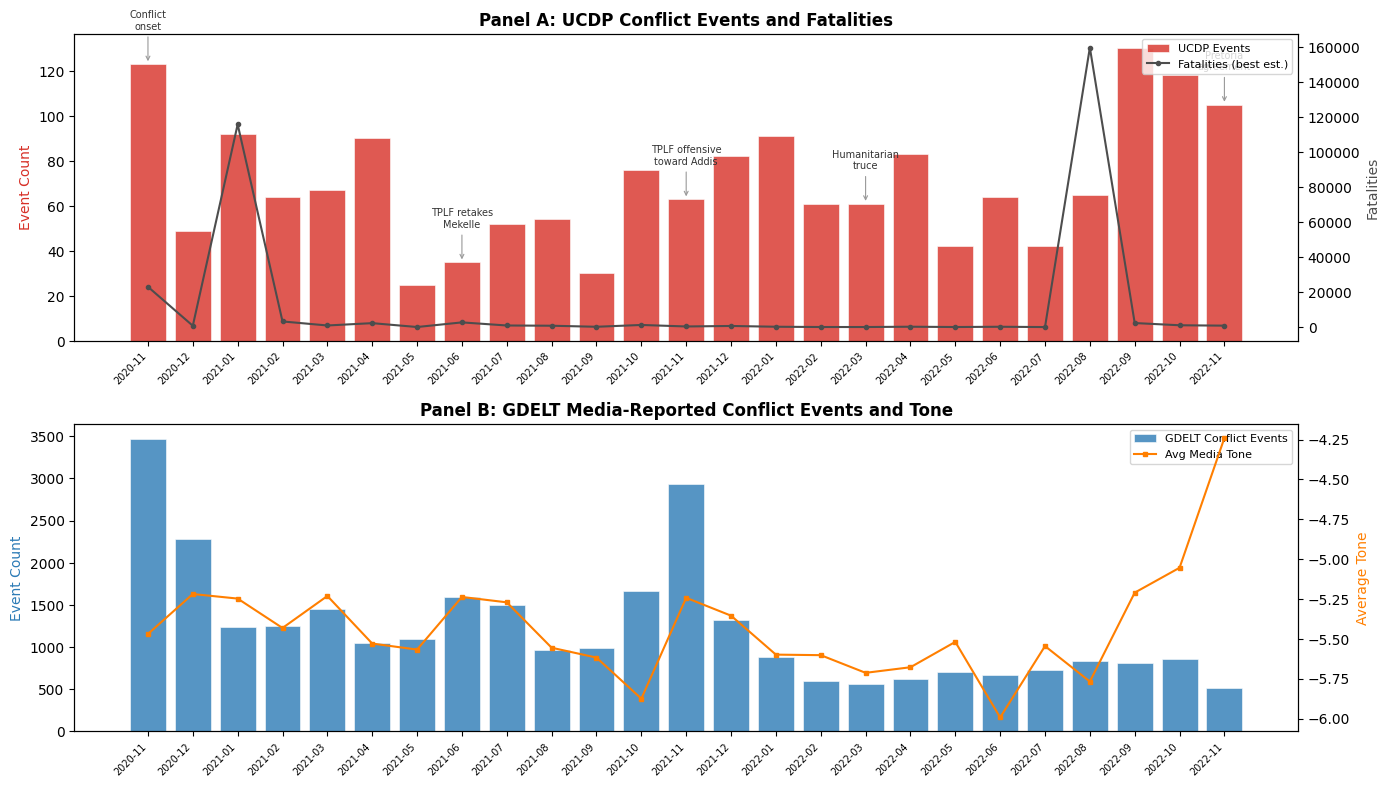

Figure saved: figures/integrated_timeseries.png


In [6]:
# Key conflict events for annotations
annotations = {
    '2020-11': 'Conflict\nonset',
    '2021-06': 'TPLF retakes\nMekelle',
    '2021-11': 'TPLF offensive\ntoward Addis',
    '2022-03': 'Humanitarian\ntruce',
    '2022-11': 'Pretoria\nagreement'
}

# Determine number of panels
n_panels = 3 if has_reliefweb else 2
height_ratios = [2, 2, 1.5] if has_reliefweb else [2, 2]

fig, axes = plt.subplots(n_panels, 1, figsize=(14, 4 * n_panels), 
                          gridspec_kw={'height_ratios': height_ratios})

x = range(len(combined))
labels = combined['year_month_str'].values

# Panel 1: UCDP events and fatalities
ax1 = axes[0]
bars1 = ax1.bar(x, combined['ucdp_events'].fillna(0), color='#d73027', 
                alpha=0.8, edgecolor='white', linewidth=0.5, label='UCDP Events')

ax1_twin = ax1.twinx()
ax1_twin.plot(x, combined['ucdp_fatalities'].fillna(0), color='#4d4d4d', 
              linewidth=1.5, marker='o', markersize=3, label='Fatalities (best est.)')
ax1_twin.set_ylabel('Fatalities', color='#4d4d4d')

ax1.set_title('Panel A: UCDP Conflict Events and Fatalities', fontsize=12, fontweight='bold')
ax1.set_ylabel('Event Count', color='#d73027')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)

# Add annotations to Panel 1
for month_str, label in annotations.items():
    if month_str in combined['year_month_str'].values:
        idx = combined[combined['year_month_str'] == month_str].index[0]
        ax1.annotate(label, xy=(idx, combined.loc[idx, 'ucdp_events']),
                     xytext=(0, 25), textcoords='offset points',
                     fontsize=7, ha='center', color='#333333',
                     arrowprops=dict(arrowstyle='->', color='#999999', lw=0.8))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# Panel 2: GDELT media events and tone
ax2 = axes[1]
ax2.bar(x, combined['gdelt_events'].fillna(0), color='#2c7bb6', 
        alpha=0.8, edgecolor='white', linewidth=0.5, label='GDELT Conflict Events')

ax2_twin = ax2.twinx()
ax2_twin.plot(x, combined['avg_tone'].fillna(0), color='#ff7f00', 
              linewidth=1.5, marker='s', markersize=3, label='Avg Media Tone')
ax2_twin.set_ylabel('Average Tone', color='#ff7f00')

ax2.set_title('Panel B: GDELT Media-Reported Conflict Events and Tone', fontsize=12, fontweight='bold')
ax2.set_ylabel('Event Count', color='#2c7bb6')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper right', fontsize=8)

# Panel 3: ReliefWeb (if available)
if has_reliefweb:
    ax3 = axes[2]
    ax3.bar(x, combined['reliefweb_reports'].fillna(0), color='#1a9850', 
            alpha=0.8, edgecolor='white', linewidth=0.5, label='ReliefWeb Reports')
    ax3.set_title('Panel C: ReliefWeb Humanitarian Reports', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Report Count', color='#1a9850')
    ax3.set_xticks(x)
    ax3.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax3.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('figures/integrated_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()

print('Figure saved: figures/integrated_timeseries.png')

## 7. Correlation Analysis

I calculate Pearson and Spearman correlation coefficients between UCDP event counts and GDELT media coverage. A high correlation would mean that media attention tracks violence intensity closely. A low or moderate correlation suggests reporting gaps or surges that decouple media coverage from actual violence.

I use both Pearson (measures linear relationship) and Spearman (measures rank-order relationship, robust to outliers) to get a complete picture. I also test the correlation between UCDP fatalities and GDELT total mentions, which measures whether higher-casualty months receive more media attention.

In [7]:
# Drop rows where either source is missing
corr_data = combined.dropna(subset=['ucdp_events', 'gdelt_events']).copy()

print('CORRELATION ANALYSIS: UCDP vs. GDELT')
print('=' * 50)
print(f'Months with both sources: {len(corr_data)}')
print()

# UCDP events vs GDELT events
pearson_r, pearson_p = stats.pearsonr(corr_data['ucdp_events'], corr_data['gdelt_events'])
spearman_r, spearman_p = stats.spearmanr(corr_data['ucdp_events'], corr_data['gdelt_events'])

print('1. UCDP Events vs. GDELT Conflict Events')
print(f'   Pearson r = {pearson_r:.3f} (p = {pearson_p:.4f})')
print(f'   Spearman rho = {spearman_r:.3f} (p = {spearman_p:.4f})')
print()

# UCDP fatalities vs GDELT total mentions
pearson_r2, pearson_p2 = stats.pearsonr(corr_data['ucdp_fatalities'], corr_data['total_mentions'])
spearman_r2, spearman_p2 = stats.spearmanr(corr_data['ucdp_fatalities'], corr_data['total_mentions'])

print('2. UCDP Fatalities vs. GDELT Total Mentions')
print(f'   Pearson r = {pearson_r2:.3f} (p = {pearson_p2:.4f})')
print(f'   Spearman rho = {spearman_r2:.3f} (p = {spearman_p2:.4f})')
print()

# UCDP events vs GDELT fight events specifically
pearson_r3, pearson_p3 = stats.pearsonr(corr_data['ucdp_events'], corr_data['fight_count'])
print('3. UCDP Events vs. GDELT Fight Events (CAMEO 19x only)')
print(f'   Pearson r = {pearson_r3:.3f} (p = {pearson_p3:.4f})')
print()

# ReliefWeb correlations if available
if has_reliefweb:
    rw_corr = corr_data.dropna(subset=['reliefweb_reports'])
    if len(rw_corr) > 5:
        r4, p4 = stats.pearsonr(rw_corr['ucdp_events'], rw_corr['reliefweb_reports'])
        print('4. UCDP Events vs. ReliefWeb Reports')
        print(f'   Pearson r = {r4:.3f} (p = {p4:.4f})')

CORRELATION ANALYSIS: UCDP vs. GDELT
Months with both sources: 25

1. UCDP Events vs. GDELT Conflict Events
   Pearson r = 0.099 (p = 0.6388)
   Spearman rho = -0.067 (p = 0.7505)

2. UCDP Fatalities vs. GDELT Total Mentions
   Pearson r = -0.005 (p = 0.9813)
   Spearman rho = 0.465 (p = 0.0191)

3. UCDP Events vs. GDELT Fight Events (CAMEO 19x only)
   Pearson r = 0.198 (p = 0.3425)



## 8. Scatter Plots: Violence vs. Reporting

I create scatter plots to visualize the relationship between UCDP violence and GDELT media coverage. Each point represents one month. Points far from the trend line indicate months where media coverage was unusually high or low relative to violence intensity.

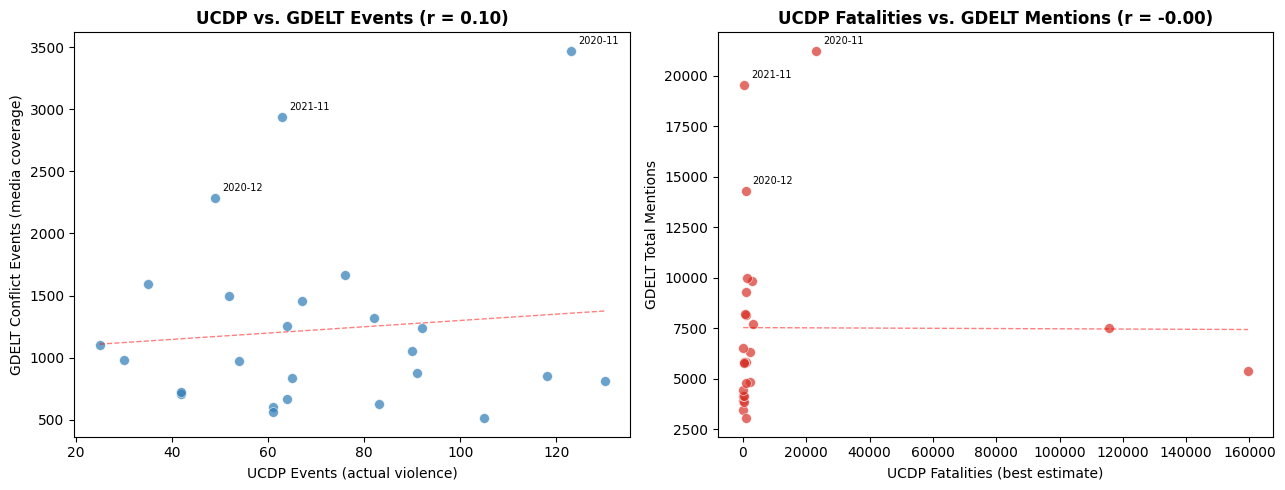

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter 1: UCDP events vs GDELT events
axes[0].scatter(corr_data['ucdp_events'], corr_data['gdelt_events'], 
                c='#2c7bb6', alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

# Add trend line
z = np.polyfit(corr_data['ucdp_events'], corr_data['gdelt_events'], 1)
p = np.poly1d(z)
x_line = np.linspace(corr_data['ucdp_events'].min(), corr_data['ucdp_events'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', alpha=0.5, linewidth=1)

# Label outlier months
for _, row in corr_data.iterrows():
    residual = row['gdelt_events'] - p(row['ucdp_events'])
    if abs(residual) > corr_data['gdelt_events'].std() * 1.2:
        axes[0].annotate(row['year_month_str'], 
                         (row['ucdp_events'], row['gdelt_events']),
                         fontsize=7, ha='left', xytext=(5, 5),
                         textcoords='offset points')

axes[0].set_xlabel('UCDP Events (actual violence)')
axes[0].set_ylabel('GDELT Conflict Events (media coverage)')
axes[0].set_title(f'UCDP vs. GDELT Events (r = {pearson_r:.2f})', fontweight='bold')

# Scatter 2: UCDP fatalities vs GDELT mentions
axes[1].scatter(corr_data['ucdp_fatalities'], corr_data['total_mentions'], 
                c='#d73027', alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

z2 = np.polyfit(corr_data['ucdp_fatalities'], corr_data['total_mentions'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(corr_data['ucdp_fatalities'].min(), corr_data['ucdp_fatalities'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), 'r--', alpha=0.5, linewidth=1)

for _, row in corr_data.iterrows():
    residual2 = row['total_mentions'] - p2(row['ucdp_fatalities'])
    if abs(residual2) > corr_data['total_mentions'].std() * 1.2:
        axes[1].annotate(row['year_month_str'],
                         (row['ucdp_fatalities'], row['total_mentions']),
                         fontsize=7, ha='left', xytext=(5, 5),
                         textcoords='offset points')

axes[1].set_xlabel('UCDP Fatalities (best estimate)')
axes[1].set_ylabel('GDELT Total Mentions')
axes[1].set_title(f'UCDP Fatalities vs. GDELT Mentions (r = {pearson_r2:.2f})', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/correlation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Identifying Reporting Gaps and Surges

I systematically identify months where media coverage (GDELT) diverges from violence intensity (UCDP). I define:

- **Reporting gap:** A month where UCDP records high violence but GDELT media coverage is low relative to the trend. This suggests underreporting, possibly due to access restrictions or communications blackouts.
- **Reporting surge:** A month where GDELT media coverage is high relative to UCDP violence levels. This suggests events that attracted disproportionate international attention, such as famine reports, diplomatic developments, or high-profile atrocities.

I identify these by computing the ratio of GDELT events to UCDP events for each month and flagging months that deviate from the median ratio.

In [9]:
# Compute GDELT-to-UCDP ratio
ratio_data = corr_data[corr_data['ucdp_events'] > 0].copy()
ratio_data['gdelt_ucdp_ratio'] = ratio_data['gdelt_events'] / ratio_data['ucdp_events']

# Compute median ratio and IQR
median_ratio = ratio_data['gdelt_ucdp_ratio'].median()
q25 = ratio_data['gdelt_ucdp_ratio'].quantile(0.25)
q75 = ratio_data['gdelt_ucdp_ratio'].quantile(0.75)
iqr = q75 - q25

# Flag gaps and surges
ratio_data['status'] = 'Normal'
ratio_data.loc[ratio_data['gdelt_ucdp_ratio'] < q25 - 0.5 * iqr, 'status'] = 'Reporting Gap'
ratio_data.loc[ratio_data['gdelt_ucdp_ratio'] > q75 + 0.5 * iqr, 'status'] = 'Reporting Surge'

print(f'Median GDELT/UCDP ratio: {median_ratio:.1f}')
print(f'IQR: [{q25:.1f}, {q75:.1f}]')
print()

# Display gaps
gaps = ratio_data[ratio_data['status'] == 'Reporting Gap'].sort_values('gdelt_ucdp_ratio')
print(f'REPORTING GAPS ({len(gaps)} months):')
print('(Low media coverage relative to violence level)')
for _, row in gaps.iterrows():
    print(f'  {row["year_month_str"]}: UCDP={int(row["ucdp_events"])} events, '
          f'GDELT={int(row["gdelt_events"])} events, '
          f'ratio={row["gdelt_ucdp_ratio"]:.1f}')
print()

# Display surges
surges = ratio_data[ratio_data['status'] == 'Reporting Surge'].sort_values('gdelt_ucdp_ratio', ascending=False)
print(f'REPORTING SURGES ({len(surges)} months):')
print('(High media coverage relative to violence level)')
for _, row in surges.iterrows():
    print(f'  {row["year_month_str"]}: UCDP={int(row["ucdp_events"])} events, '
          f'GDELT={int(row["gdelt_events"])} events, '
          f'ratio={row["gdelt_ucdp_ratio"]:.1f}')

Median GDELT/UCDP ratio: 16.8
IQR: [9.9, 28.2]

REPORTING GAPS (0 months):
(Low media coverage relative to violence level)

REPORTING SURGES (4 months):
(High media coverage relative to violence level)
  2021-11: UCDP=63 events, GDELT=2938 events, ratio=46.6
  2020-12: UCDP=49 events, GDELT=2285 events, ratio=46.6
  2021-06: UCDP=35 events, GDELT=1594 events, ratio=45.5
  2021-05: UCDP=25 events, GDELT=1098 events, ratio=43.9


## 10. Visualizing Reporting Gaps and Surges

I create a visualization that highlights the months with reporting gaps and surges. The bars show the GDELT-to-UCDP ratio for each month, with color coding for gaps (red), surges (blue), and normal months (gray).

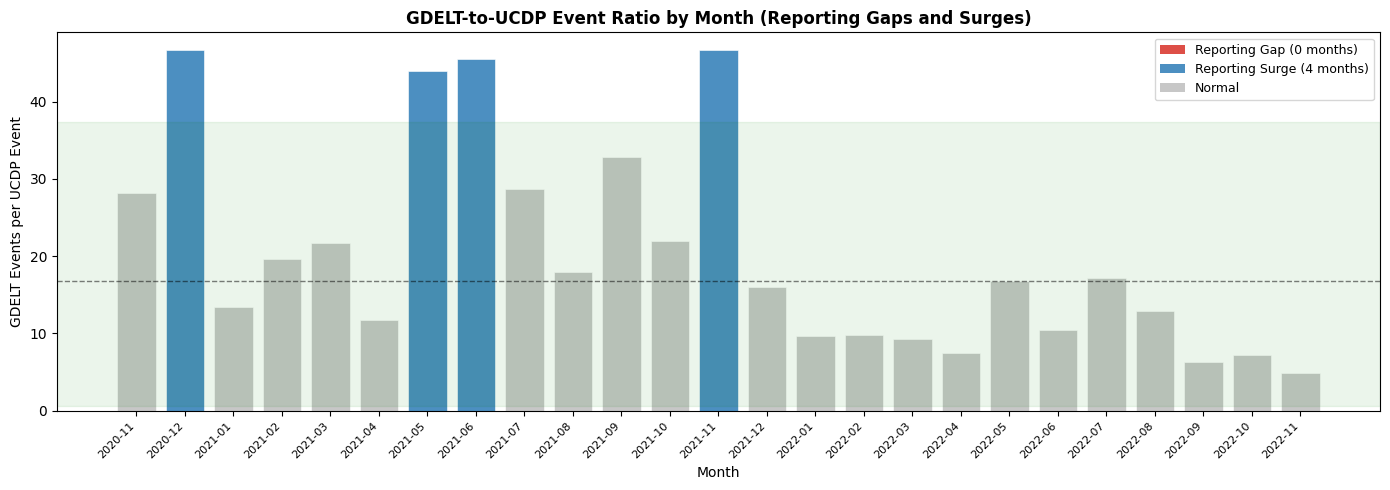

In [10]:
# Plot GDELT/UCDP ratio with gap/surge coloring
fig, ax = plt.subplots(figsize=(14, 5))

colors = []
for s in ratio_data['status']:
    if s == 'Reporting Gap':
        colors.append('#d73027')  # Red
    elif s == 'Reporting Surge':
        colors.append('#2c7bb6')  # Blue
    else:
        colors.append('#bdbdbd')  # Gray

bars = ax.bar(range(len(ratio_data)), ratio_data['gdelt_ucdp_ratio'].values, 
              color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)

# Add median line
ax.axhline(y=median_ratio, color='black', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Median ratio ({median_ratio:.1f})')

# Add IQR band
ax.axhspan(q25 - 0.5 * iqr, q75 + 0.5 * iqr, alpha=0.08, color='green',
           label='Normal range')

ax.set_xticks(range(len(ratio_data)))
ax.set_xticklabels(ratio_data['year_month_str'].values, rotation=45, ha='right', fontsize=8)
ax.set_title('GDELT-to-UCDP Event Ratio by Month (Reporting Gaps and Surges)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('GDELT Events per UCDP Event')
ax.set_xlabel('Month')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', alpha=0.85, label=f'Reporting Gap ({len(gaps)} months)'),
    Patch(facecolor='#2c7bb6', alpha=0.85, label=f'Reporting Surge ({len(surges)} months)'),
    Patch(facecolor='#bdbdbd', alpha=0.85, label='Normal')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/reporting_gaps_surges.png', dpi=200, bbox_inches='tight')
plt.show()

## 11. Normalized Time Series Comparison

To compare UCDP and GDELT on the same scale, I normalize both series to a 0-1 range using min-max normalization. This removes the effect of different absolute magnitudes and shows the relative temporal patterns. Months where the normalized lines diverge indicate reporting discrepancies.

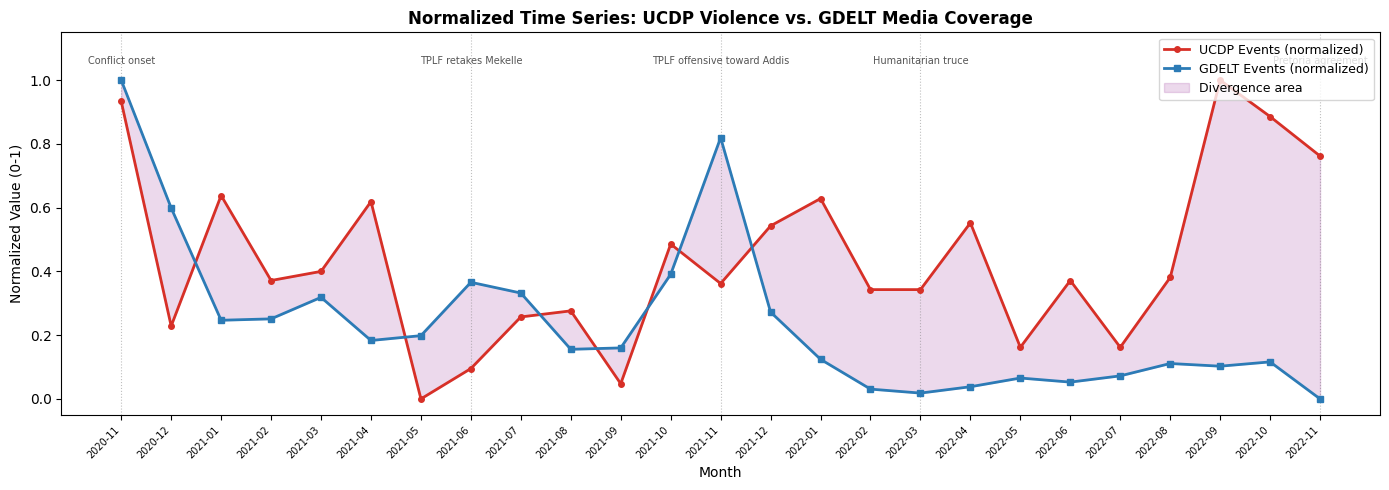

In [11]:
# Min-max normalize both series
def normalize(series):
    s = series.fillna(0)
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else s * 0

fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(combined))

ax.plot(x, normalize(combined['ucdp_events']), color='#d73027', linewidth=2,
        marker='o', markersize=4, label='UCDP Events (normalized)', zorder=3)
ax.plot(x, normalize(combined['gdelt_events']), color='#2c7bb6', linewidth=2,
        marker='s', markersize=4, label='GDELT Events (normalized)', zorder=3)

if has_reliefweb:
    ax.plot(x, normalize(combined['reliefweb_reports']), color='#1a9850', linewidth=2,
            marker='^', markersize=4, label='ReliefWeb Reports (normalized)', zorder=3)

# Shade areas where sources diverge
ucdp_norm = normalize(combined['ucdp_events']).values
gdelt_norm = normalize(combined['gdelt_events']).values
ax.fill_between(x, ucdp_norm, gdelt_norm, alpha=0.15, color='purple',
                label='Divergence area')

# Annotations
for month_str, label in annotations.items():
    if month_str in combined['year_month_str'].values:
        idx = combined[combined['year_month_str'] == month_str].index[0]
        ax.axvline(x=idx, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)
        ax.text(idx, 1.05, label.replace('\n', ' '), fontsize=7, ha='center',
                rotation=0, color='#555555')

ax.set_xticks(x)
ax.set_xticklabels(combined['year_month_str'].values, rotation=45, ha='right', fontsize=7)
ax.set_title('Normalized Time Series: UCDP Violence vs. GDELT Media Coverage', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)')
ax.set_xlabel('Month')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.savefig('figures/normalized_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Save Combined Dataset

I save the combined monthly dataset for reference and potential reuse.

In [12]:
# Save combined dataset
df_save = combined.copy()
df_save['year_month'] = df_save['year_month'].astype(str)
df_save.to_csv('data/processed/combined_monthly_analysis.csv', index=False, encoding='utf-8')
print(f'Combined data saved: data/processed/combined_monthly_analysis.csv ({len(df_save)} rows)')

Combined data saved: data/processed/combined_monthly_analysis.csv (25 rows)


## 13. Findings Summary

I summarize the key findings from the integration analysis.

In [13]:
print('=' * 60)
print('INTEGRATION ANALYSIS FINDINGS')
print('=' * 60)
print()
print('DATA SOURCES INTEGRATED:')
print(f'  UCDP GED v25.1: {ucdp_monthly["ucdp_events"].sum()} events across {len(ucdp_monthly)} months')
print(f'  GDELT (BigQuery): {int(combined["gdelt_events"].sum())} conflict events across {combined["gdelt_events"].notna().sum()} months')
if has_reliefweb:
    print(f'  ReliefWeb API: {int(combined["reliefweb_reports"].sum())} reports across {combined["reliefweb_reports"].notna().sum()} months')
else:
    print(f'  ReliefWeb API: pending (appname approval needed)')
print()

print('CORRELATION RESULTS:')
print(f'  UCDP events vs. GDELT events: r = {pearson_r:.3f} (p = {pearson_p:.4f})')
print(f'  UCDP fatalities vs. GDELT mentions: r = {pearson_r2:.3f} (p = {pearson_p2:.4f})')
sig_label = 'statistically significant' if pearson_p < 0.05 else 'not statistically significant'
print(f'  The event-count correlation is {sig_label} at p < 0.05.')
print()

print('REPORTING GAPS AND SURGES:')
print(f'  Reporting gaps identified: {len(gaps)} months')
if len(gaps) > 0:
    print(f'  Gap months: {", ".join(gaps["year_month_str"].values)}')
print(f'  Reporting surges identified: {len(surges)} months')
if len(surges) > 0:
    print(f'  Surge months: {", ".join(surges["year_month_str"].values)}')
print()

print('FILES SAVED:')
print('  data/processed/combined_monthly_analysis.csv')
print('  figures/integrated_timeseries.png')
print('  figures/correlation_scatter.png')
print('  figures/reporting_gaps_surges.png')
print('  figures/normalized_comparison.png')
print('=' * 60)

INTEGRATION ANALYSIS FINDINGS

DATA SOURCES INTEGRATED:
  UCDP GED v25.1: 1764 events across 25 months
  GDELT (BigQuery): 30601 conflict events across 25 months
  ReliefWeb API: pending (appname approval needed)

CORRELATION RESULTS:
  UCDP events vs. GDELT events: r = 0.099 (p = 0.6388)
  UCDP fatalities vs. GDELT mentions: r = -0.005 (p = 0.9813)
  The event-count correlation is not statistically significant at p < 0.05.

REPORTING GAPS AND SURGES:
  Reporting gaps identified: 0 months
  Reporting surges identified: 4 months
  Surge months: 2021-11, 2020-12, 2021-06, 2021-05

FILES SAVED:
  data/processed/combined_monthly_analysis.csv
  figures/integrated_timeseries.png
  figures/correlation_scatter.png
  figures/reporting_gaps_surges.png
  figures/normalized_comparison.png
